#         DataVine Analytics


# 1. Business Understanding
DataVine Analyst is an organization that deals with business consultation, analysis and creating models for solving problems the businesses are faced with.

The task is to make 3 models for 3 clients.

These are:
* **Wine Classification System** for A premium wine distributor needs a model to automatically classify wine based on their chemical properties for inventory management and quality control. For this, KNN with PCA will be used to create an accurate classification model
* **Agricultural Feed Recommendation Engine** for an agricultural supply company who wants to recommend similar feed types to farmers based on perfomance data i.e. Chickwts Dataset. Using the chicken weights dataset as a proxy, you'll build a recommendation system that leverages PCA and similarity metrics to suggest comparable feed products that might produce similar results.
* **Regional Crime Pattern Analysis** for a public policy research firm requesting a data-driven approach to identify patterns in crime statistaic across different regions. Clustering techniques (K-Mean and Gaussian Mixture Models) will be applied to discover natural groupings in crime data, using feature selection and dimensionality reduction to focus on the most relevant patterns.

# 2. Data Understanding
There are 3 datasets to make models from:
* Wine Dataset
* Chickwts Dataset
* USArrests Dataset

## I. Wine Dataset
The Wine dataset contains chemical measurements of wines, with a categorical target indicating the wine class

Here is its characteristics
* It has 178 rows and 14 columns
* It has no missing data
* Here's a table with the column names and their datatypes:

    |Column Name|Datatype|
    | :--- | :---|
    |Wine|int64|
    |Alcohol|float64|
    |Malic.acid|float64|
    |Ash|float64|
    |Acl|float64|
    |Mg|int64|
    |Phenols|float64|
    |Flavanoids|float64|
    |Nonflavanoid.phenols|float64|
    |Proanth|float64|
    |Color.int|float64|
    |Hue|float64|
    |OD|float64|
    |Proline|int64|

## II. Chickwts Dataset
This dataset contains data about chicken weights and the feed products they consume.

Here is its characterictis:
* It has 71 rows and 3 columns
* It has no missing data
* Here's a table with the column names and their datatypes:

|Column name|Data types|
| :--- |:--- |
|rownames|int64|
|weight|int64|
|feed|object|

## III. USArrests Dataset
This is a dataset that contains data of regions with the crime rates.

Here is its characterictis:
* It has 50 rows and 5 columns
* It has no missing data
* Here's a table with the column names and their datatypes

|Column Name|Data type|
| :--- | :--- |
|Murder|float|
|Assault|int64|
|UrbanPop|int64|
|Rape|float|
|State|object|

In [1]:
# Import the necessary libraries
import pandas as pd # for data manipulation
import numpy as np # for numerical computations
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for plotting

# Import scikit-learn libraries
from sklearn.model_selection import train_test_split, GridSearchCV # for splitting data and hyperparameter tuning
from sklearn.preprocessing import StandardScaler, LabelEncoder # for feature scaling
from sklearn.neighbors import KNeighborsClassifier # for KNN classification
from sklearn.metrics import accuracy_score, classification_report, silhouette_score # for model evaluation
from sklearn.decomposition import PCA # for dimensionality reduction
from sklearn.cluster import KMeans # for clustering
from sklearn.mixture import GaussianMixture # for Gaussian Mixture Models
from sklearn.metrics.pairwise import cosine_similarity # for similarity calculations

In [ ]:
# Dataset 1: Wine (for KNN classification)
wine_df = pd.read_csv('wine.csv')

# Dataset 2: Chickwts (for Recommendation System)
chickwts_df = pd.read_csv('chickwts.csv')

# Dataset 3: USArrests (for PCA and Clustering)
usarrests_df = pd.read_csv('USArrests.csv')

# Display the first few rows of each dataset
print("Wine Dataset:")
print(wine_df.head())
print("\nChickwts Dataset:")
print(chickwts_df.head())
print("\nUSArrests Dataset:")
print(usarrests_df.head())

Wine Dataset:
   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  

Chickwts Dataset:
   rownames  weight       feed
0         1     179  horsebean
1         2     160  horsebean
2         3     136  horsebean
3         4     227 

### Wine Dataset

In [ ]:
# Displaying the first 5 rows of wine dataset
wine_df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
# Checking the shape of the wine dataset
wine_df.shape

(178, 14)

In [ ]:
# Checking for missing values in the wine dataset
wine_df.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [ ]:
# Checking the data types of each column in the wine dataset
wine_df.dtypes

Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

In [ ]:
# Checking the statistical summary of the wine dataset
wine_df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Chickwts Dataset

In [ ]:
# Displaying the first 5 rows of chickwts dataset
chickwts_df.head()

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [ ]:
# Checking the shape of the chickwts dataset
chickwts_df.shape

(71, 3)

In [ ]:
# Checking for missing values in the chickwts dataset
chickwts_df.isnull().sum()

rownames    0
weight      0
feed        0
dtype: int64

In [ ]:
# Checking the data types of each column in the chickwts dataset
chickwts_df.dtypes

rownames     int64
weight       int64
feed        object
dtype: object

In [ ]:
# Checking the statistical summary of the Chickwts dataset
chickwts_df.describe()

,rownames,weight
count,71.000000,71.000000
mean,36.000000,261.309859
std,20.639767,78.073700
min,1.000000,108.000000
25%,18.500000,204.500000
50%,36.000000,258.000000
75%,53.500000,323.500000
max,71.000000,423.000000


### USArrests Dataset

In [ ]:
# Displaying the first 5 rows of USArrests dataset
usarrests_df.head()

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [ ]:
# Checking the shape of the USArrests dataset
usarrests_df.shape

(50, 5)

In [ ]:
# Checking for missing values in the USArrests dataset
usarrests_df.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

In [ ]:
# Checking the data types of each column in the USArrests dataset
usarrests_df.dtypes

Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
State        object
dtype: object

In [ ]:
# Checking the statistical summary of the USArrests dataset
usarrests_df.describe()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


# 3. Data Preparation

### Preparing wine dataset

In [ ]:
# Separating predictors and target
X_wine = wine_df.drop(columns=["Wine"])
y_wine_raw = wine_df["Wine"]

# Converting target labels to numeric values
label_encoder = LabelEncoder()
y_wine = label_encoder.fit_transform(y_wine_raw)

# Stratified split preserves the class proportions in train and test sets
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.20,
    random_state=42,
    stratify=y_wine
)

# Standardizing using training data only
wine_scaler = StandardScaler()
X_train_wine_scaled = wine_scaler.fit_transform(X_train_wine)
X_test_wine_scaled = wine_scaler.transform(X_test_wine)

# PCA retaining 95% of variance
wine_pca = PCA(n_components=0.95)
X_train_wine_pca = wine_pca.fit_transform(X_train_wine_scaled)
X_test_wine_pca = wine_pca.transform(X_test_wine_scaled)

print("Original number of features:", X_wine.shape[1])
print("PCA components retained:", wine_pca.n_components_)
print("Explained variance retained:", wine_pca.explained_variance_ratio_.sum())
print("Class labels:", dict(enumerate(label_encoder.classes_)))

Original number of features: 13
PCA components retained: 10
Explained variance retained: 0.9624355601767978
Class labels: {0: np.int64(1), 1: np.int64(2), 2: np.int64(3)}


### Preparing Chickwts dataset

In [ ]:
# Aggregating chicken-level observations to one profile per feed type
feed_summary = (
    chickwts_df.groupby("feed", as_index=False)
    .agg(mean_weight=("weight", "mean"),
         weight_std=("weight", "std"),
         observations=("weight", "size"))
)

# Weight feature standardization
chick_scaler = StandardScaler()
feed_weight_scaled = chick_scaler.fit_transform(feed_summary[["mean_weight"]])

# PCA to one principal component
chick_pca = PCA(n_components=1)
feed_pca = chick_pca.fit_transform(feed_weight_scaled)
feed_summary["PC1"] = feed_pca[:, 0]

print("Feed-level profiles:")
display(feed_summary.sort_values("mean_weight", ascending=False))
print("PCA explained variance:", chick_pca.explained_variance_ratio_.sum())

# Cosine similarity between feed types
feed_similarity = cosine_similarity(feed_pca)
feed_similarity_df = pd.DataFrame(
    feed_similarity,
    index=feed_summary["feed"],
    columns=feed_summary["feed"]
)

print("Cosine similarity matrix:")
display(feed_similarity_df.round(3))

Feed-level profiles:


,feed,mean_weight,weight_std,observations,PC1
5,sunflower,328.916667,48.836384,12,1.181855
0,casein,323.583333,64.433840,12,1.091532
3,meatmeal,276.909091,64.900623,11,0.301077
4,soybean,246.428571,54.129068,14,-0.215128
2,linseed,218.750000,52.235698,12,-0.683880
1,horsebean,160.200000,38.625841,10,-1.675457


PCA explained variance: 1.0
Cosine similarity matrix:


feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


### Preparing USArrest dataset

Murder, Assault, and Rape were selected as the three most relevant features
because they directly measure reported crime intensity. UrbanPop measures the
percentage of the population living in urban areas and is a demographic
indicator rather than a direct crime-rate measure. State was retained only as
an identifier and excluded from numerical clustering.

In [ ]:
# Selecting the three crime-rate variables for clustering
crime_features = ["Murder", "Assault", "Rape"]
X_usa = usarrests_df[crime_features].copy()

# Standardizing the selected clustering features
usa_scaler = StandardScaler()
X_usa_scaled = usa_scaler.fit_transform(X_usa)

# Reducing to two principal components
usa_pca = PCA(n_components=2)
X_usa_pca = usa_pca.fit_transform(X_usa_scaled)

print("Selected features:", crime_features)
print("PCA explained variance ratio:", usa_pca.explained_variance_ratio_)
print("Total variance retained by 2 components:", usa_pca.explained_variance_ratio_.sum())

Selected features: ['Murder', 'Assault', 'Rape']
PCA explained variance ratio: [0.7861934  0.15268378]
Total variance retained by 2 components: 0.9388771782627571


# 4. Modeling

### K-Nearest Neighbors (K-NN) on wine dataset

In [ ]:
# Hyperparameter tuning for KNN using GridSearchCV to find the best number of neighbors and distance metric
param_grid = {
    'n_neighbors': list(range(1, 21)), # Testing neighbors from 1 to 20
    'metric': ['euclidean', 'manhattan', 'minkowski'] # Different distance metrics
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_wine_pca, y_train_wine)

# Getting the best parameters and best score from the grid search
best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
print(f"Best k: {best_k}, Best Metric: {best_metric}")

# Training the KNN classifier with the best parameters
knn_classifier = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_classifier.fit(X_train_wine_pca, y_train_wine)

# Making predictions on the test set
y_pred_wine = knn_classifier.predict(X_test_wine_pca)

print("k-NN Classification Report:\n", classification_report(y_test_wine, y_pred_wine))
print(f"k-NN Accuracy: {accuracy_score(y_test_wine, y_pred_wine):.2f}")

Best k: 18, Best Metric: euclidean
k-NN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

k-NN Accuracy: 1.00


### Recommendation System using Chickwts dataset

In [ ]:
def recommend_feeds(feed_name, num_recommendations=3):
    feed_name = str(feed_name)
    if feed_name not in set(feed_summary["feed"]):
        raise ValueError(f"Unknown feed type: {feed_name}")

    query_idx = feed_summary.index[feed_summary["feed"] == feed_name][0]
    scores = feed_similarity[query_idx]

    results = feed_summary[["feed", "mean_weight"]].copy()
    results["cosine_similarity"] = scores
    query_weight = feed_summary.loc[query_idx, "mean_weight"]
    results["weight_difference"] = (results["mean_weight"] - query_weight).abs()

    # Excluding the queried feed itself.
    results = results[results["feed"] != feed_name].copy()
    positive = results[results["cosine_similarity"] > 0].sort_values(
        ["cosine_similarity", "weight_difference"], ascending=[False, True]
    )
    fallback = results[results["cosine_similarity"] <= 0].sort_values(
        "weight_difference", ascending=True
    )

    recommendations = pd.concat([positive, fallback], ignore_index=True)
    recommendations = recommendations.drop_duplicates(subset=["feed"]).head(num_recommendations)
    recommendations["basis"] = np.where(
        recommendations["cosine_similarity"] > 0,
        "positive cosine similarity; weight proximity breaks ties",
        "fallback: closest mean weight because 1D cosine is non-positive"
    )
    return recommendations.reset_index(drop=True)

query_feed = "soybean"
recommendations = recommend_feeds(query_feed, num_recommendations=3)
print(f"Recommended feeds for {query_feed}:")
display(recommendations)

Recommended feeds for soybean:


,feed,mean_weight,cosine_similarity,weight_difference,basis
0,linseed,218.750000,1.0,27.678571,positive cosine similarity; weight proximity b...
1,horsebean,160.200000,1.0,86.228571,positive cosine similarity; weight proximity b...
2,meatmeal,276.909091,-1.0,30.480519,fallback: closest mean weight because 1D cosin...


### Clustering (K-Means & GMM) on the USArrests dataset

K-Means inertia by k:
 k  inertia
 1  140.832
 2   47.124
 3   32.872
 4   19.509
 5   15.883
 6   13.120
 7   10.480
 8    8.375
 9    7.152
10    6.223

Elbow-selected number of clusters: 2


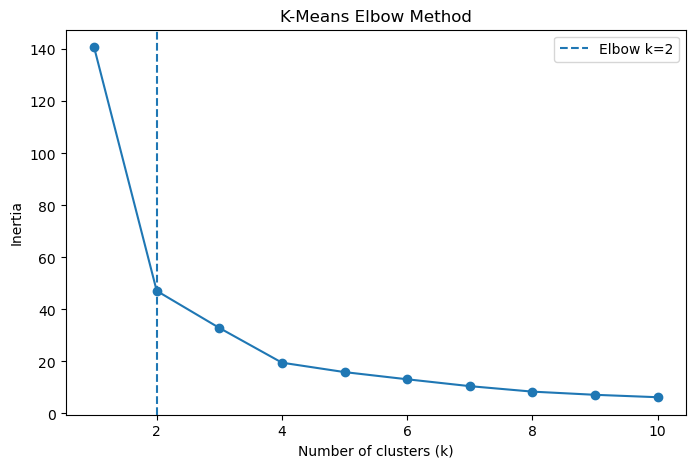

In [ ]:
# Calculating K-Means inertia for k = 1 to 10
k_values = range(1, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_usa_pca)
    inertias.append(km.inertia_)

# Elbow detection using maximum distance from the line connecting first and last points
x = np.asarray(list(k_values), dtype=float)
y = np.asarray(inertias, dtype=float)
line_start = np.array([x[0], y[0]])
line_end = np.array([x[-1], y[-1]])
line_vec = line_end - line_start

distances = []
for xi, yi in zip(x, y):
    point = np.array([xi, yi])
    cross_product = abs(line_vec[0] * (point[1] - line_start[1]) - line_vec[1] * (point[0] - line_start[0]))
    distances.append(cross_product / np.linalg.norm(line_vec))

distances = np.asarray(distances)
best_k_kmeans = int(x[np.argmax(distances)])

print("K-Means inertia by k:")
print(pd.DataFrame({"k": list(k_values), "inertia": inertias}).round(3).to_string(index=False))
print(f"\nElbow-selected number of clusters: {best_k_kmeans}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.axvline(best_k_kmeans, linestyle="--", label=f"Elbow k={best_k_kmeans}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.legend()
plt.show()

In [ ]:
# Fit final K-Means model
kmeans_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_usa_pca)

# GMM: select the number of components using the lowest BIC
bic_results = []
for k in range(1, 11):
    gmm_model = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm_model.fit(X_usa_pca)
    bic_results.append({"components": k, "BIC": gmm_model.bic(X_usa_pca)})

bic_df = pd.DataFrame(bic_results)
best_gmm_k = int(bic_df.loc[bic_df["BIC"].idxmin(), "components"])
lowest_bic = float(bic_df["BIC"].min())

print("GMM BIC results:")
display(bic_df.round(3))
print(f"Best GMM components according to BIC: {best_gmm_k}")
print(f"Lowest BIC: {lowest_bic:.3f}")

# Fit final GMM
gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=42, n_init=10)
gmm_labels = gmm_final.fit_predict(X_usa_pca)

# Store results for interpretation
usa_results = usarrests_df.copy()
usa_results["KMeans_Cluster"] = kmeans_labels
usa_results["GMM_Cluster"] = gmm_labels

print("\nK-Means cluster sizes:")
print(usa_results["KMeans_Cluster"].value_counts().sort_index())
print("\nGMM cluster sizes:")
print(usa_results["GMM_Cluster"].value_counts().sort_index())

GMM BIC results:


,components,BIC
0,1,307.212
1,2,293.280
2,3,303.990
3,4,316.699
4,5,317.340
5,6,319.161
6,7,332.714
7,8,326.483
8,9,335.576
9,10,326.728


Best GMM components according to BIC: 2
Lowest BIC: 293.280

K-Means cluster sizes:
KMeans_Cluster
0    30
1    20
Name: count, dtype: int64

GMM cluster sizes:
GMM_Cluster
0    31
1    19
Name: count, dtype: int64


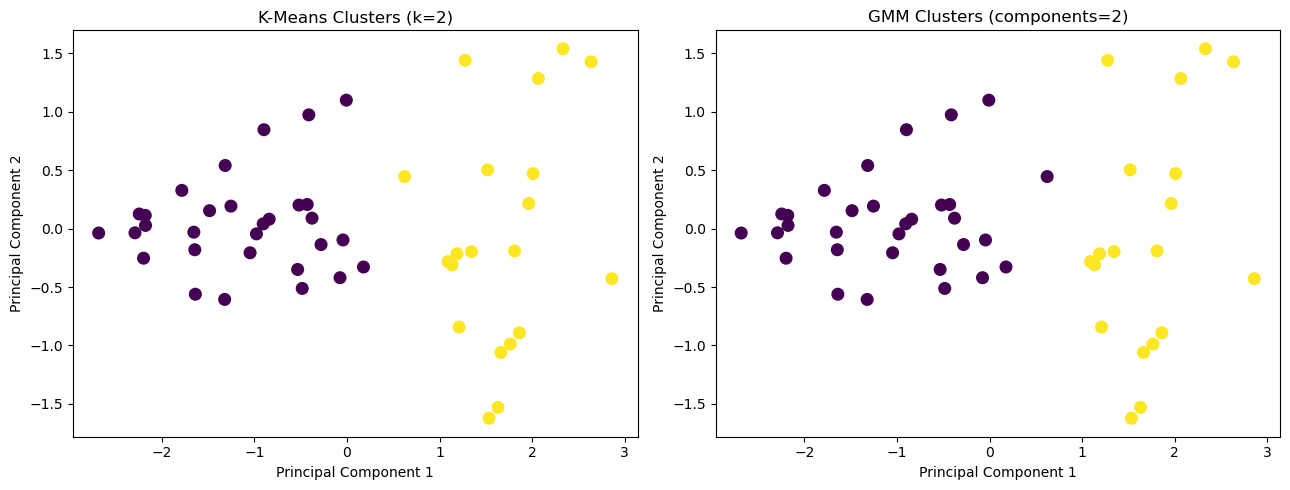

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_usa_pca[:, 0], X_usa_pca[:, 1], c=kmeans_labels, s=70)
axes[0].set_title(f"K-Means Clusters (k={best_k_kmeans})")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(X_usa_pca[:, 0], X_usa_pca[:, 1], c=gmm_labels, s=70)
axes[1].set_title(f"GMM Clusters (components={best_gmm_k})")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

# 5. Evaluation
## 5.1. K-Nearest Neighbors on Wine Dataset
GridSearchCV was used to identify the best K-NN parameters. The best number of neighbors was 18, using the Euclidean distance metric.
The K-NN model achieved an accuracy of 100% on the test dataset, indicating that it performed very well in classifying the wine types.
The classification report was also used to evaluate the model's precision, recall, and F1-score.

## 5.2. Recommendation System using Chickwts dataset
The recommendation system uses cosine similarity to identify feed types with similar performance.
The feed data was standardized and reduced to one principal component using PCA before calculating similarity.
The system provides the top three recommended feed types based on their similarity to the selected feed.
Because the recommendation uses a single feature, some cosine similarity scores are tied; therefore, the similarity results should be interpreted alongside the feed weight values.

## 5.3. Clustering on USArrest dataset (Using K-Means and GMM)
### 5.3.1. K-Means clustering
The elbow method was used to determine the appropriate number of clusters.
The elbow method indicated that 2 clusters were appropriate for the data.
K-Means was then applied to group the states based on their crime patterns.

### 5.3.2. GMM
Gaussian Mixture Models were tested using different numbers of components.
Bayesian Information Criterion (BIC) was used to select the best number of components.
The lowest BIC was obtained with 2 components, so the GMM model used 2 clusters.
The K-Means and GMM results were visualized and compared to identify the crime-pattern groupings in the dataset.